# Backtest

## 1. Run

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from market_maker import MarketMaker

df = pd.read_parquet('data/raw/book.parquet')

mm = MarketMaker()
results = mm.run(df)

print(mm.exchange.summary())
print(f'Total fills:  {len(mm.exchange.fills)}')
print(f'Final PnL:    ${results["pnl"].iloc[-1]:.4f}')
print(f'Final inventory: {results["inventory"].iloc[-1]:.4f} BTC')

{'total_fills': 0, 'total_fees_paid_usd': 0, 'open_orders': 2, 'cancelled_orders': 9998}
Total fills:  0
Final PnL:    $0.0000
Final inventory: 0.0000 BTC


## 2. PnL

Sharpe:        nan
Max drawdown:  $0.0000


/var/folders/zk/2p1tzxbd6ysfl4_7650h0jbw0000gp/T/ipykernel_9189/2934554249.py:2: RuntimeWarning: invalid value encountered in scalar divide
  sharpe      = pnl_returns.mean() / pnl_returns.std() * np.sqrt(len(pnl_returns))


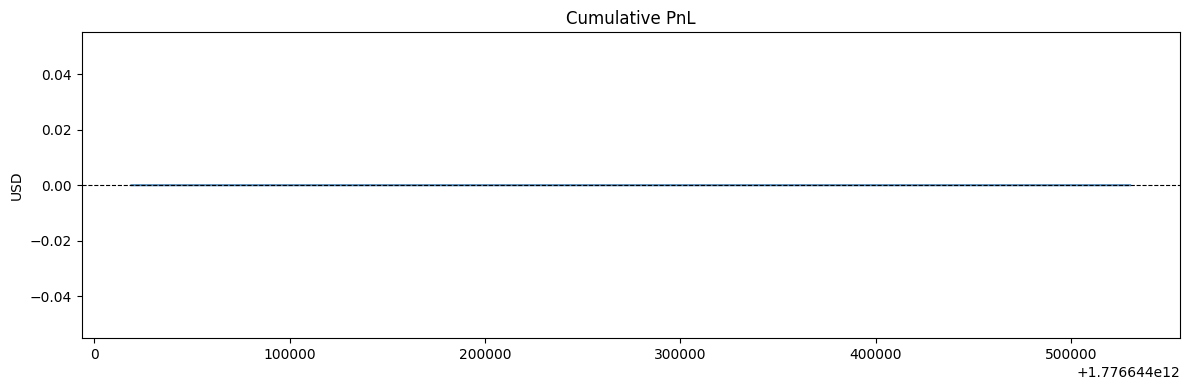

In [2]:
pnl_returns = results['pnl'].diff().dropna()
sharpe      = pnl_returns.mean() / pnl_returns.std() * np.sqrt(len(pnl_returns))
max_dd      = (results['pnl'] - results['pnl'].cummax()).min()

print(f'Sharpe:        {sharpe:.3f}')
print(f'Max drawdown:  ${max_dd:.4f}')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(results['timestamp'], results['pnl'], color='steelblue')
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_title('Cumulative PnL')
ax.set_ylabel('USD')
plt.tight_layout()
plt.savefig('data/processed/pnl.png', dpi=150)
plt.show()

## 3. Inventory

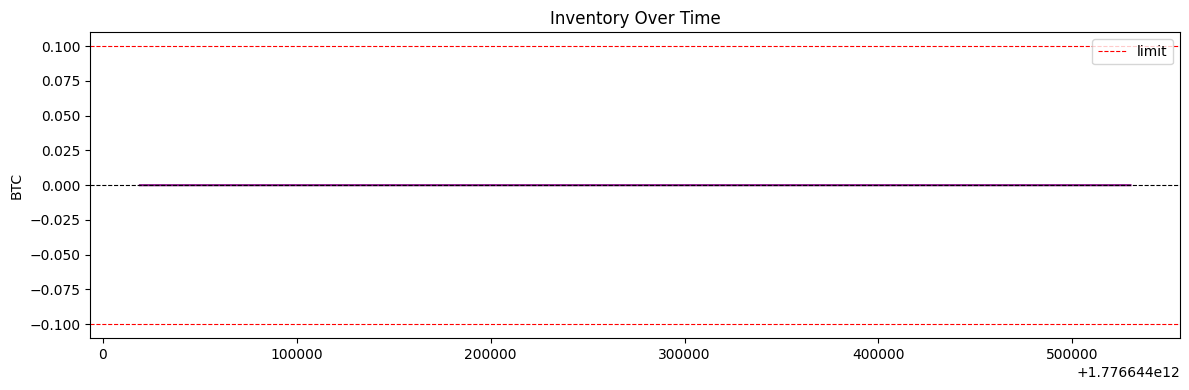

In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(results['timestamp'], results['inventory'], color='purple')
ax.axhline(0,  color='black',  linestyle='--', linewidth=0.8)
ax.axhline( mm.max_inventory, color='red', linestyle='--', linewidth=0.8, label='limit')
ax.axhline(-mm.max_inventory, color='red', linestyle='--', linewidth=0.8)
ax.set_title('Inventory Over Time')
ax.set_ylabel('BTC')
ax.legend()
plt.tight_layout()
plt.savefig('data/processed/inventory.png', dpi=150)
plt.show()

## 4. Spread vs Volatility

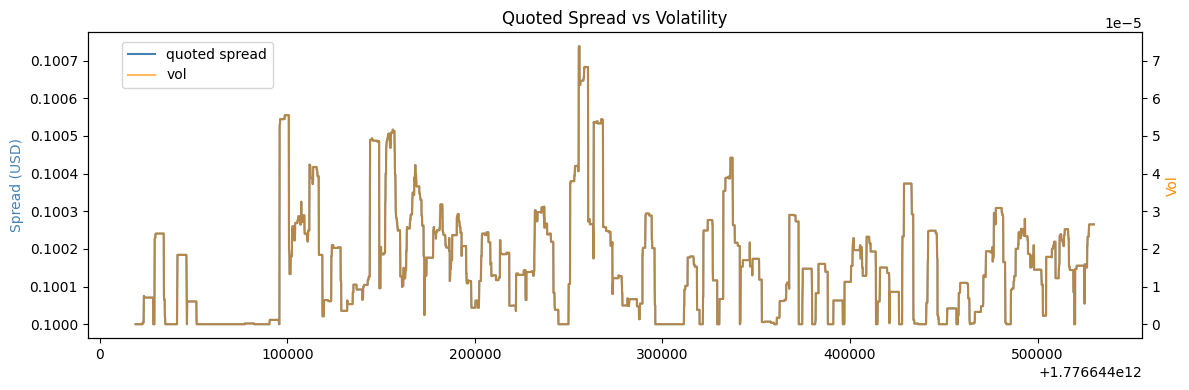

In [4]:
# show vol-adjusted quoting behaviour
base_half = mm.half_spread_ticks
quoted_spread = 2 * (base_half + results['vol'] * mm.vol_scalar)

fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()
ax1.plot(results['timestamp'], quoted_spread, color='steelblue', label='quoted spread')
ax2.plot(results['timestamp'], results['vol'],  color='darkorange', alpha=0.6, label='vol')
ax1.set_title('Quoted Spread vs Volatility')
ax1.set_ylabel('Spread (USD)', color='steelblue')
ax2.set_ylabel('Vol', color='darkorange')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.savefig('data/processed/spread_vol.png', dpi=150)
plt.show()

## 5. Fill Analysis

In [5]:
fills_df = pd.DataFrame([
    {'side': f.side, 'price': f.price, 'size': f.size, 'fee': f.fee, 'timestamp': f.timestamp}
    for f in mm.exchange.fills
])

if not fills_df.empty:
    buy_fills  = (fills_df['side'] == 'buy').sum()
    sell_fills = (fills_df['side'] == 'sell').sum()
    fill_rate  = len(fills_df) / len(results)

    print(f'Buy fills:   {buy_fills}')
    print(f'Sell fills:  {sell_fills}')
    print(f'Fill rate:   {fill_rate:.2%}')
    print(f'Total fees:  ${fills_df["fee"].sum():.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # buy vs sell fill count
    axes[0].bar(['buy', 'sell'], [buy_fills, sell_fills], color=['steelblue', 'darkorange'])
    axes[0].set_title('Buy vs Sell Fills')
    axes[0].set_ylabel('Count')

    # fill size distribution
    axes[1].hist(fills_df['size'], bins=20, color='steelblue')
    axes[1].set_title('Fill Size Distribution')
    axes[1].set_xlabel('BTC')

    plt.tight_layout()
    plt.savefig('data/processed/fills.png', dpi=150)
    plt.show()
else:
    print('No fills recorded.')

No fills recorded.


## 6. Summary

In [6]:
print('=== Strategy Summary ===')
print(f'Steps:            {len(results)}')
print(f'Total fills:      {len(mm.exchange.fills)}')
print(f'Fill rate:        {len(mm.exchange.fills) / len(results):.2%}')
print(f'Final PnL:        ${results["pnl"].iloc[-1]:.4f}')
print(f'Sharpe:           {sharpe:.3f}')
print(f'Max drawdown:     ${max_dd:.4f}')
print(f'Total fees paid:  ${mm.exchange.total_fees_paid:.4f}')
print(f'Final inventory:  {results["inventory"].iloc[-1]:.6f} BTC')

=== Strategy Summary ===
Steps:            5000
Total fills:      0
Fill rate:        0.00%
Final PnL:        $0.0000
Sharpe:           nan
Max drawdown:     $0.0000
Total fees paid:  $0.0000
Final inventory:  0.000000 BTC


In [7]:
# print bid/ask being generated
mid = (df.iloc[0]['bid_0_price'] + df.iloc[0]['ask_0_price']) / 2
print(f"mid: {mid}")
print(f"best ask: {df.iloc[0]['ask_0_price']}")
print(f"best bid: {df.iloc[0]['bid_0_price']}")

mm_test = MarketMaker()
bid, ask = mm_test.generate_quotes(mid, vol=0.00002, obi=0.0)
print(f"my bid: {bid}, my ask: {ask}")

mid: 74016.55
best ask: 74016.6
best bid: 74016.5
my bid: 74016.5, my ask: 74016.6


In [8]:
df['spread'].describe()

count    5000.000000
mean        0.102240
std         0.084619
min         0.100000
25%         0.100000
50%         0.100000
75%         0.100000
max         5.300000
Name: spread, dtype: float64